In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('crimes.csv')
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [3]:
df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4)
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H%M').dt.time
print(df[['TIME OCC']].head())

   TIME OCC
0  11:10:00
1  16:20:00
2  12:00:00
3  06:35:00
4  09:00:00


In [7]:
null_counts = df.isnull().sum()
print(null_counts)

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64


In [13]:
null_percentages = (df.isnull().sum() / len(df)) * 100

In [14]:
missing_data = pd.DataFrame({
    'Total Missing': null_counts,
    'Percentage (%)': null_percentages
})

print("تقرير القيم الفارغة في البيانات:")
print(missing_data)

تقرير القيم الفارغة في البيانات:
              Total Missing  Percentage (%)
DR_NO                     0        0.000000
Date Rptd                 0        0.000000
DATE OCC                  0        0.000000
TIME OCC                  0        0.000000
AREA NAME                 0        0.000000
Crm Cd Desc               0        0.000000
Vict Age                  0        0.000000
Vict Sex                 11        0.005923
Vict Descent             10        0.005385
Weapon Desc          112213       60.422152
Status Desc               0        0.000000
LOCATION                  0        0.000000


In [18]:
weapon_nulls = df[df['Weapon Desc'].isnull()]
print(f"عدد الصفوف التي ليس بها سلاح: {len(weapon_nulls)}")
display(weapon_nulls.head())

عدد الصفوف التي ليس بها سلاح: 112213


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,11:10:00,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,16:20:00,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,12:00:00,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,06:35:00,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,09:00:00,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [17]:
no_weapon_df = df[df['Weapon Desc'].isnull()][['Crm Cd Desc', 'Weapon Desc']]
print("أمثلة لجرائم تمت بدون سلاح:")
display(no_weapon_df.head(20))
print("\nأكثر 10 جرائم تكراراً ولا يوجد بها سلاح في بياناتك:")
print(no_weapon_df['Crm Cd Desc'].value_counts().head(10))

أمثلة لجرائم تمت بدون سلاح:


,Crm Cd Desc,Weapon Desc
0,THEFT OF IDENTITY,NaN
1,THEFT OF IDENTITY,NaN
2,THEFT OF IDENTITY,NaN
3,THEFT OF IDENTITY,NaN
4,THEFT OF IDENTITY,NaN
5,THEFT OF IDENTITY,NaN
6,THEFT OF IDENTITY,NaN
7,THEFT OF IDENTITY,NaN
8,BURGLARY,NaN
10,THEFT OF IDENTITY,NaN



أكثر 10 جرائم تكراراً ولا يوجد بها سلاح في بياناتك:
Crm Cd Desc
THEFT OF IDENTITY                                           22668
BURGLARY FROM VEHICLE                                       13051
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)         11384
THEFT PLAIN - PETTY ($950 & UNDER)                          10325
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)      9847
BURGLARY                                                     9053
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD     6829
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                     3695
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)              2962
VIOLATION OF RESTRAINING ORDER                               2906
Name: count, dtype: int64


In [19]:
crime_counts = df['Crm Cd Desc'].value_counts()
crime_counts_df = crime_counts.reset_index()
crime_counts_df.columns = ['نوع الجريمة', 'عدد الحوادث']
print("قائمة أنواع الجرائم وأعدادها في الملف:")
display(crime_counts_df)

قائمة أنواع الجرائم وأعدادها في الملف:


,نوع الجريمة,عدد الحوادث
0,THEFT OF IDENTITY,22670
1,BATTERY - SIMPLE ASSAULT,19694
2,BURGLARY FROM VEHICLE,13799
3,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",13215
4,INTIMATE PARTNER - SIMPLE ASSAULT,11981
...,...,...
99,BRIBERY,1
100,GRAND THEFT / INSURANCE FRAUD,1
101,DISRUPT SCHOOL,1
102,FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS ...,1


In [20]:
identity_theft_all = df[df['Crm Cd Desc'] == 'THEFT OF IDENTITY']
identity_theft_no_weapon = identity_theft_all[identity_theft_all['Weapon Desc'].isnull()]
total_id_theft = len(identity_theft_all)
no_weapon_id_theft = len(identity_theft_no_weapon)
percentage = (no_weapon_id_theft / total_id_theft) * 100
print(f"إجمالي جرائم سرقة الهوية: {total_id_theft}")
print(f"جرائم سرقة الهوية بدون سلاح: {no_weapon_id_theft}")
print(f"النسبة المئوية: {percentage:.2f}%")

# إذا أردت التأكد هل يوجد أصلاً حالات سرقة هوية بسلاح؟
with_weapon_id_theft = identity_theft_all[identity_theft_all['Weapon Desc'].notnull()]
print(f"جرائم سرقة الهوية التي سُجل بها سلاح: {len(with_weapon_id_theft)}")

إجمالي جرائم سرقة الهوية: 22670
جرائم سرقة الهوية بدون سلاح: 22668
النسبة المئوية: 99.99%
جرائم سرقة الهوية التي سُجل بها سلاح: 2


In [21]:
# تصفية البيانات: سرقة هوية + السلاح ليس فارغاً
identity_with_weapon = df[(df['Crm Cd Desc'] == 'THEFT OF IDENTITY') & (df['Weapon Desc'].notnull())]

# عرض الأعمدة المهمة فقط لرؤية السلاح
print(f"عرض الـ {len(identity_with_weapon)} حالة 'سرقة هوية' اللي اتسجل فيها سلاح:")
display(identity_with_weapon[['DR_NO', 'Crm Cd Desc', 'Weapon Desc', 'Vict Age', 'Vict Sex']])

عرض الـ 2 حالة 'سرقة هوية' اللي اتسجل فيها سلاح:


,DR_NO,Crm Cd Desc,Weapon Desc,Vict Age,Vict Sex
57505,221918517,THEFT OF IDENTITY,HAND GUN,40,F
74491,221317194,THEFT OF IDENTITY,UNKNOWN WEAPON/OTHER WEAPON,32,M


In [22]:
# حساب عدد جرائم سرقة الهوية فقط
identity_theft_count = len(df[df['Crm Cd Desc'] == 'THEFT OF IDENTITY'])

print(f"إجمالي عدد جرائم سرقة الهوية في الملف هو: {identity_theft_count}")

إجمالي عدد جرائم سرقة الهوية في الملف هو: 22670


In [23]:
df.loc[(df['Crm Cd Desc'] == 'THEFT OF IDENTITY') & (df['Weapon Desc'].isnull()), 'Weapon Desc'] = 'No Weapon'

# للتأكد من النتيجة:
check = df[df['Crm Cd Desc'] == 'THEFT OF IDENTITY']['Weapon Desc'].value_counts()
print("\nتوزيع حالات السلاح داخل جرائم سرقة الهوية بعد التعديل:")
print(check)


توزيع حالات السلاح داخل جرائم سرقة الهوية بعد التعديل:
Weapon Desc
No Weapon                      22668
HAND GUN                           1
UNKNOWN WEAPON/OTHER WEAPON        1
Name: count, dtype: int64


In [26]:
# 1. تصفية الصفوف التي لا تزال تحتوي على قيم فارغة في عمود السلاح
remaining_nulls = df[df['Weapon Desc'].isnull()]

# 2. حساب عدد القيم الفارغة لكل نوع جريمة
null_by_crime = remaining_nulls['Crm Cd Desc'].value_counts()

# 3. عرض النتيجة
print("أنواع الجرائم التي لا تزال تحتوي على قيم سلاح فارغة وأعدادها:")
print(null_by_crime)

# 4. حساب الإجمالي العام للقيم الفارغة المتبقية
print(f"\nإجمالي القيم الفارغة المتبقية في عمود السلاح: {remaining_nulls.shape[0]}")

أنواع الجرائم التي لا تزال تحتوي على قيم سلاح فارغة وأعدادها:
Series([], Name: count, dtype: int64)

إجمالي القيم الفارغة المتبقية في عمود السلاح: 0


In [25]:
# 1. تعريف الجمل المناسبة لكل نوع جريمة (للخانات الفارغة فقط)
mapping_dict = {
    'THEFT OF IDENTITY': 'Digital/Paper Crime',
    'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD': 'Non-Confrontational Theft',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Non-Confrontational Theft',
    'TRESPASSING': 'Unlawful Entry Only'
}

# 2. وظيفة لتعبئة الفراغ بناءً على نوع الجريمة
def fill_weapon_logic(row):
    # إذا كانت خانة السلاح فارغة ونوع الجريمة موجود في القاموس بتاعنا
    if pd.isnull(row['Weapon Desc']) and row['Crm Cd Desc'] in mapping_dict:
        return mapping_dict[row['Crm Cd Desc']]
    else:
        return row['Weapon Desc']

# 3. تطبيق الوظيفة على الداتا
df['Weapon Desc'] = df.apply(fill_weapon_logic, axis=1)

# 4. أي جريمة أخرى لسه فارغة نكتب عنها "Under Investigation" أو "Not Specified"
df['Weapon Desc'] = df['Weapon Desc'].fillna('Not Specified')

# عرض النتيجة للتأكد
print("تم تحديث وصف السلاح بجمل منطقية:")
display(df[['Crm Cd Desc', 'Weapon Desc']].head(20))

تم تحديث وصف السلاح بجمل منطقية:


,Crm Cd Desc,Weapon Desc
0,THEFT OF IDENTITY,No Weapon
1,THEFT OF IDENTITY,No Weapon
2,THEFT OF IDENTITY,No Weapon
3,THEFT OF IDENTITY,No Weapon
4,THEFT OF IDENTITY,No Weapon
5,THEFT OF IDENTITY,No Weapon
6,THEFT OF IDENTITY,No Weapon
7,THEFT OF IDENTITY,No Weapon
8,BURGLARY,Not Specified
9,OTHER MISCELLANEOUS CRIME,VERBAL THREAT


In [27]:
df['Vict Sex'] = df['Vict Sex'].fillna('Not Specified')
df['Vict Sex'] = df['Vict Sex'].replace(['', ' ', 'X'], 'Not Specified')

#  عرض توزيع الجنس الجديد للتأكد
print("توزيع جنس الضحايا بعد التعديل:")
print(df['Vict Sex'].value_counts())

# عرض عينة للبيانات التي تم تعديلها
display(df[['Vict Age', 'Vict Sex', 'Crm Cd Desc']].head(10))

توزيع جنس الضحايا بعد التعديل:
Vict Sex
M                93008
F                89854
Not Specified     2823
H                   30
Name: count, dtype: int64


,Vict Age,Vict Sex,Crm Cd Desc
0,27,F,THEFT OF IDENTITY
1,60,M,THEFT OF IDENTITY
2,28,M,THEFT OF IDENTITY
3,37,M,THEFT OF IDENTITY
4,79,M,THEFT OF IDENTITY
5,28,F,THEFT OF IDENTITY
6,33,M,THEFT OF IDENTITY
7,35,M,THEFT OF IDENTITY
8,72,M,BURGLARY
9,21,F,OTHER MISCELLANEOUS CRIME


In [28]:
# 1. استخراج الـ 10 صفوف اللي فيهم العرق مفقود
missing_descent = df[df['Vict Descent'].isnull()]

# 2. ربطهم بنوع الجريمة والمنطقة والجنس
correlation = missing_descent[['Crm Cd Desc', 'AREA NAME', 'Vict Sex']]

print("تحليل الـ 10 سجلات المفقودة في Vict Descent:")
display(correlation)

# 3. معرفة أكثر جريمة يتكرر فيها فقدان بيانات العرق
print("\nأكثر الجرائم تكراراً مع بيانات عرق مفقودة:")
print(missing_descent['Crm Cd Desc'].value_counts())

تحليل الـ 10 سجلات المفقودة في Vict Descent:


,Crm Cd Desc,AREA NAME,Vict Sex
32086,DISCHARGE FIREARMS/SHOTS FIRED,Southeast,Not Specified
38511,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,Foothill,Not Specified
38738,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Rampart,Not Specified
48786,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Rampart,Not Specified
65540,BURGLARY,N Hollywood,Not Specified
92698,VANDALISM - MISDEAMEANOR ($399 OR UNDER),Rampart,Not Specified
110168,BURGLARY FROM VEHICLE,Central,Not Specified
119171,BURGLARY,Central,Not Specified
147398,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",Southwest,Not Specified
150654,BATTERY - SIMPLE ASSAULT,Wilshire,F



أكثر الجرائم تكراراً مع بيانات عرق مفقودة:
Crm Cd Desc
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)    2
BURGLARY                                                   2
DISCHARGE FIREARMS/SHOTS FIRED                             1
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)        1
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                   1
BURGLARY FROM VEHICLE                                      1
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT             1
BATTERY - SIMPLE ASSAULT                                   1
Name: count, dtype: int64


In [29]:
import pandas as pd
import numpy as np

# 1. تحديد الـ 10 صفوف اللي فيهم العرق مفقود
mask = df['Vict Descent'].isnull()

# 2. ربطهم بكلمة "Unknown" مع إضافة وصف الجريمة بشكل مختصر (كبديل احترافي)
# هنعمل ده بحيث لو الجريمة سرقة هوية نكتب Unknown - Identity Theft
def bridge_missing_descent(row):
    if pd.isnull(row['Vict Descent']):
        if row['Crm Cd Desc'] == 'THEFT OF IDENTITY':
            return 'Unknown (Remote Crime)'
        else:
            return 'Unknown (Incomplete Report)'
    return row['Vict Descent']

# 3. تطبيق التعديل
df['Vict Descent'] = df.apply(bridge_missing_descent, axis=1)

# 4. التأكد من النتيجة
print("تم ربط الـ 10 حالات المفقودة بأسماء تعبر عن سبب النقص:")
print(df['Vict Descent'].value_counts().filter(like='Unknown'))

تم ربط الـ 10 حالات المفقودة بأسماء تعبر عن سبب النقص:
Vict Descent
Unknown (Incomplete Report)    10
Name: count, dtype: int64


In [30]:
# 1. متوسط أعمار الضحايا لكل نوع جريمة
age_analysis = df.groupby('Crm Cd Desc')['Vict Age'].mean().sort_values(ascending=False)

# 2. أكثر 5 مناطق تكرر فيها الجرائم
top_areas = df['AREA NAME'].value_counts().head(5)

# 3. توزيع الجرائم حسب الجنس
sex_distribution = df['Vict Sex'].value_counts(normalize=True) * 100

print("متوسط أعمار الضحايا حسب الجريمة:\n", age_analysis)
print("\nأخطر 5 مناطق:\n", top_areas)
print("\nنسبة توزيع الجنس للضحايا:\n", sex_distribution)

متوسط أعمار الضحايا حسب الجريمة:
 Crm Cd Desc
PURSE SNATCHING - ATTEMPT                                   62.500000
DISRUPT SCHOOL                                              62.000000
GRAND THEFT / INSURANCE FRAUD                               62.000000
DISHONEST EMPLOYEE ATTEMPTED THEFT                          60.000000
DOCUMENT FORGERY / STOLEN FELONY                            53.696011
                                                              ...    
TILL TAP - GRAND THEFT ($950.01 & OVER)                     23.000000
HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE                   22.413793
REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)    21.500000
CONTRIBUTING                                                15.437500
CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)    10.906445
Name: Vict Age, Length: 104, dtype: float64

أخطر 5 مناطق:
 AREA NAME
Central        14944
Southwest      11945
77th Street    11739
Pacific         9923
Hollywood       9762
Name: cou

### 📊 **Victim Age Group Analysis | تحليل فئات أعمار الضحايا**
---
* **EN:** The 18-45 age group is the most targeted, indicating that active citizens are at higher risk. The presence of seniors (60+) in identity theft data suggests a need for specialized digital protection programs for the elderly.
* **AR:** الفئة العمرية 18-45 هي الأكثر استهدافاً، مما يشير إلى أن المواطنين الأكثر نشاطاً هم الأكثر عرضة للمخاطر. وجود كبار السن (60+) في بيانات سرقة الهوية يستوجب إطلاق برامج حماية رقمية متخصصة لكبار السن.

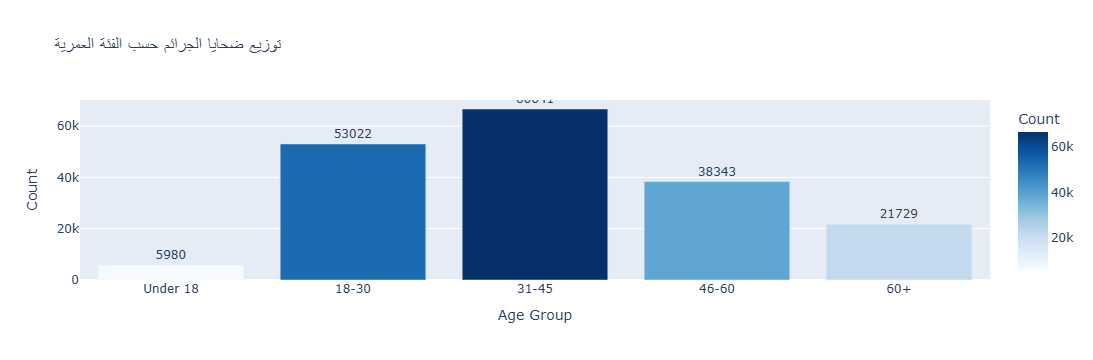

In [32]:
import plotly.express as px

# 1. تجهيز فئات الأعمار
bins = [0, 18, 30, 45, 60, 100]
labels = ['Under 18', '18-30', '31-45', '46-60', '60+']
df['Age Group'] = pd.cut(df['Vict Age'], bins=bins, labels=labels)
age_dist = df['Age Group'].value_counts().sort_index().reset_index()
age_dist.columns = ['Age Group', 'Count']

# 2. الرسم التفاعلي
fig_age = px.bar(age_dist, x='Age Group', y='Count', 
                 text='Count', # إظهار الرقم فوق العمود
                 title='توزيع ضحايا الجرائم حسب الفئة العمرية',
                 color='Count', # تدرج ألوان حسب العدد
                 color_continuous_scale='Blues')

fig_age.update_traces(texttemplate='%{text}', textposition='outside')
fig_age.show()

### 🚻 **Gender Distribution | توزيع جنس الضحايا**
---
* **EN:** Crime victimization is closely balanced between genders. High 'Not Specified' entries often correlate with remote or digital crimes where physical contact is absent, requiring better data collection for online reporting.
* **AR:** ضحايا الجرائم متقاربون بين الجنسين. الارتباط العالي للقيم 'غير المحددة' بالجرائم الرقمية أو عن بُعد (حيث يغيب الاتصال الجسدي) يتطلب تحسين آليات جمع البيانات في البلاغات الإلكترونية.

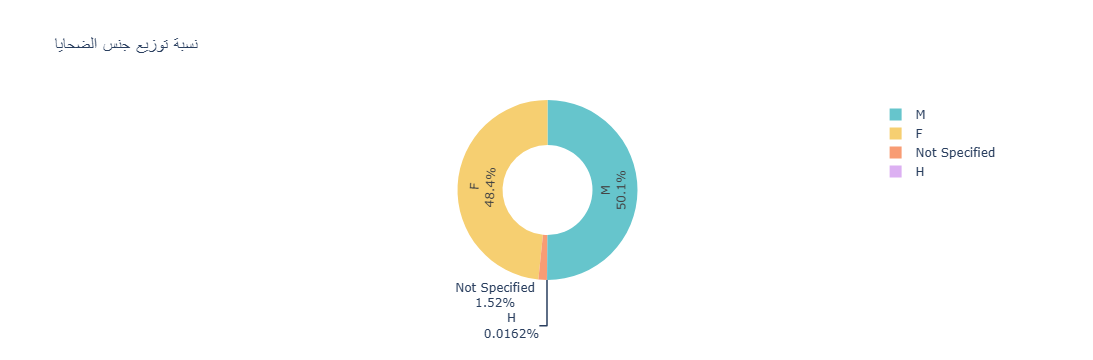

In [33]:
# حساب توزيع الجنس
sex_dist = df['Vict Sex'].value_counts().reset_index()
sex_dist.columns = ['Gender', 'Count']

# الرسم التفاعلي
fig_sex = px.pie(sex_dist, values='Count', names='Gender', 
                 hole=0.5, # جعلها شكل "الدونات"
                 title='نسبة توزيع جنس الضحايا',
                 color_discrete_sequence=px.colors.qualitative.Pastel)

fig_sex.update_traces(textinfo='percent+label')
fig_sex.show()

### 🚨 **Top 10 Most Frequent Crimes | أعلى 10 جرائم تكراراً**
---
* **EN:** Identity Theft dominates the list, shifting the threat from physical to digital. Strategic recommendation: Reallocate police resources toward cybercrime units and public awareness about financial data security.
* **AR:** سرقة الهوية تهيمن على القائمة، مما ينقل التهديد من مادي إلى رقمي. توصية استراتيجية: إعادة توجيه الموارد الشرطية نحو وحدات الجرائم السيبرانية وتوعية الجمهور حول أمن البيانات المالية.

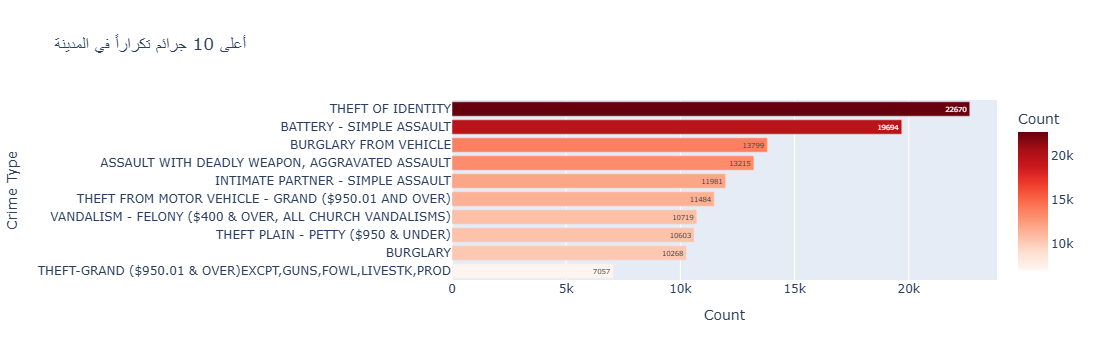

In [34]:
# حساب أعلى 10 جرائم
top_crimes = df['Crm Cd Desc'].value_counts().head(10).reset_index()
top_crimes.columns = ['Crime Type', 'Count']

# الرسم التفاعلي
fig_crimes = px.bar(top_crimes, x='Count', y='Crime Type', 
                    orientation='h', # رسم أفقي لسهولة قراءة الأسماء
                    title='أعلى 10 جرائم تكراراً في المدينة',
                    color='Count',
                    color_continuous_scale='Reds',
                    text='Count')

fig_crimes.update_layout(yaxis={'categoryorder':'total ascending'}) # ترتيب من الأكبر للأصغر
fig_crimes.show()

### 📍 **Crime Distribution by Area | توزيع الجرائم حسب المنطقة**
---
* **EN:** Each district shows a unique 'Crime Signature'. Districts with high trespassing rates need urban design interventions (lighting, fencing), while identity theft hotspots require intelligence-led policing.
* **AR:** تظهر كل منطقة 'بصمة إجرامية' فريدة. المناطق ذات معدلات التعدي العالية تحتاج لتدخلات في التصميم العمراني (إضاءة، أسوار)، بينما بؤر سرقة الهوية تتطلب عملاً استخباراتياً تقنياً.

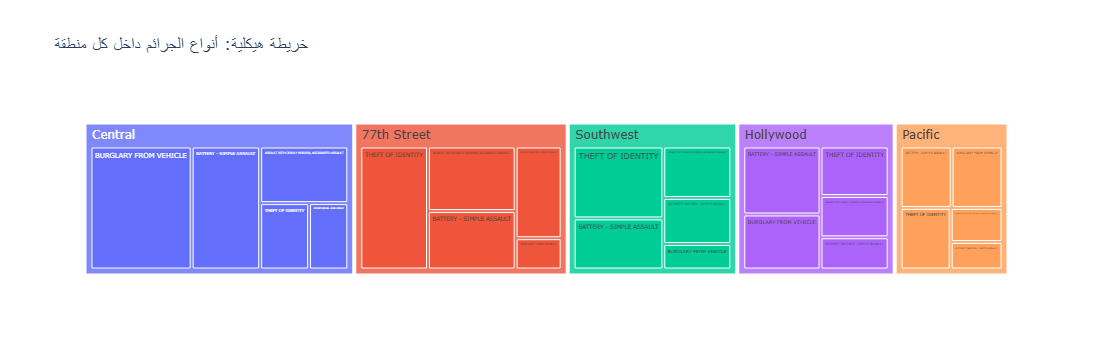

In [35]:
# اختيار أعلى 5 مناطق وأعلى 5 جرائم للتبسيط
top_areas = df['AREA NAME'].value_counts().head(5).index
top_crime_types = df['Crm Cd Desc'].value_counts().head(5).index
df_filtered = df[(df['AREA NAME'].isin(top_areas)) & (df['Crm Cd Desc'].isin(top_crime_types))]

# رسم الـ TreeMap
fig_tree = px.treemap(df_filtered, path=['AREA NAME', 'Crm Cd Desc'], 
                      title='خريطة هيكلية: أنواع الجرائم داخل كل منطقة')
fig_tree.show()